# Local Outlier Factor (LOF) – Anomaly Detection

Local Outlier Factor (LOF) is a **density-based anomaly detection algorithm** that identifies anomalies by comparing the **local density** of a point to its neighbors.  

- **Normal points**: Reside in dense regions  
- **Anomalies**: Have lower density compared to neighbors  

---

## Steps for LOF Anomaly Detection

### 1. Import Libraries
```python
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt

✅ healthcare.csv file created successfully!

   patient_id  age  heart_rate  blood_pressure_sys  blood_pressure_dia  \
0           1   25          72                 120                  80   
1           2   34          78                 125                  82   
2           3   45          85                 130                  85   
3           4   52          88                 135                  88   
4           5   29          76                 118                  78   

   glucose_level   bmi  cholesterol  
0             90  22.5          180  
1             95  24.1          190  
2            110  27.8          210  
3            115  29.3          220  
4             88  23.0          175  

Detected Anomalies:
    patient_id  age  heart_rate  blood_pressure_sys  blood_pressure_dia  \
12          13   67          95                 150                  95   

    glucose_level   bmi  cholesterol  anomaly anomaly_label  lof_score  
12            150  32.8          250 

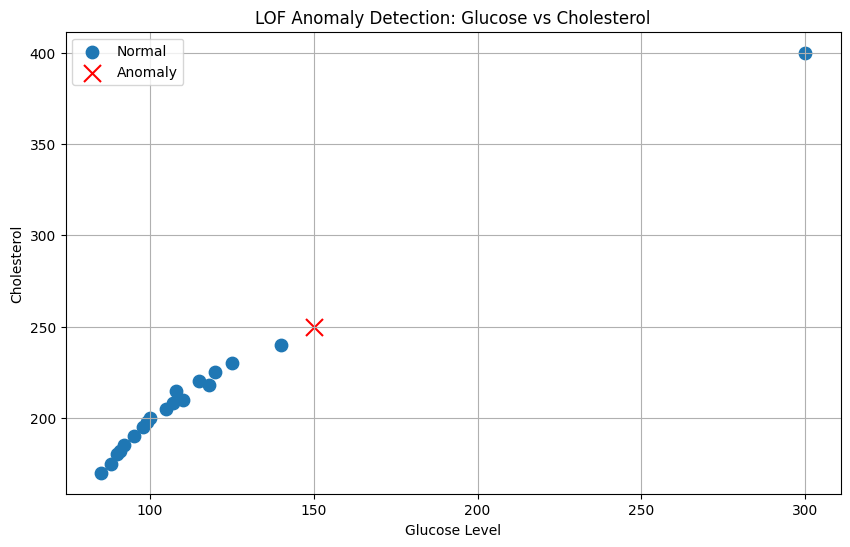

/var/folders/l5/brjnv_593qdf8cbh4v4ch0840000gn/T/ipykernel_4460/3852011055.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['heart_rate'], df['blood_pressure_sys'], df['glucose_level'], df['cholesterol']],


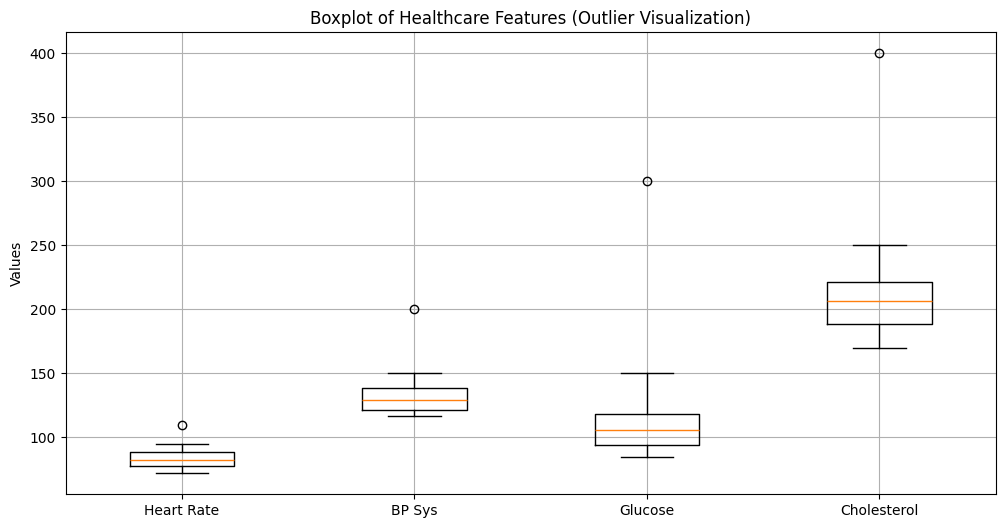

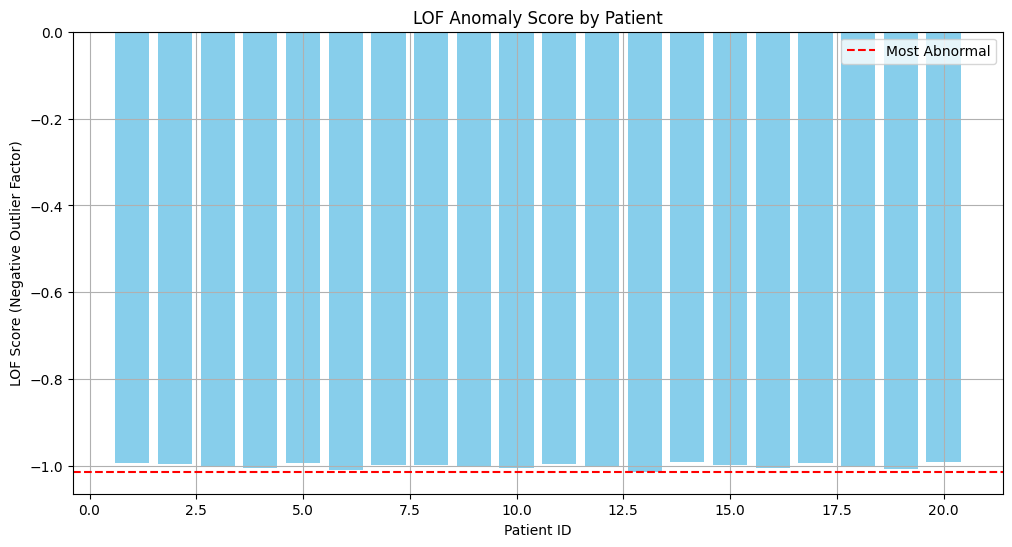


Top 5 Most Abnormal Patients:
    patient_id anomaly_label  lof_score
12          13       Anomaly  -1.013430
5            6        Normal  -1.010476
18          19        Normal  -1.007032
9           10        Normal  -1.005617
15          16        Normal  -1.004235
3            4        Normal  -1.003987
8            9        Normal  -1.002126
2            3        Normal  -1.001597
17          18        Normal  -1.000987
11          12        Normal  -1.000109
6            7        Normal  -0.998742
14          15        Normal  -0.998205
7            8        Normal  -0.997397
1            2        Normal  -0.996456
10          11        Normal  -0.995135
16          17        Normal  -0.994403
0            1        Normal  -0.993903
4            5        Normal  -0.993050
19          20        Normal  -0.991893
13          14        Normal  -0.991893


In [1]:
# ==========================================
# Healthcare Anomaly Detection using LOF
# ==========================================

# 1️⃣ Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# ==========================================
# 2️⃣ Create Sample Healthcare Dataset
# ==========================================
data = {
    'patient_id': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    'age': [25,34,45,52,29,61,40,37,48,55,33,42,67,28,39,50,31,46,58,70],
    'heart_rate': [72,78,85,88,76,92,80,79,84,90,77,82,95,74,81,87,75,83,89,110],
    'blood_pressure_sys': [120,125,130,135,118,145,128,122,132,140,121,129,150,117,126,138,119,131,142,200],
    'blood_pressure_dia': [80,82,85,88,78,92,84,81,86,90,79,83,95,77,82,89,78,85,91,130],
    'glucose_level': [90,95,110,115,88,140,100,98,108,120,92,105,150,85,99,118,91,107,125,300],
    'bmi': [22.5,24.1,27.8,29.3,23.0,31.5,26.2,25.4,28.1,30.0,24.8,27.0,32.8,22.9,25.8,29.0,23.7,27.5,30.5,45.0],
    'cholesterol': [180,190,210,220,175,240,200,195,215,225,185,205,250,170,198,218,182,208,230,400]
}

df = pd.DataFrame(data)

# Save CSV (optional)
df.to_csv('healthcare.csv', index=False)
print("✅ healthcare.csv file created successfully!\n")
print(df.head())

# ==========================================
# 3️⃣ Select Features for LOF
# ==========================================
features = ['age', 'heart_rate', 'blood_pressure_sys', 'blood_pressure_dia', 
            'glucose_level', 'bmi', 'cholesterol']
X = df[features]

# ==========================================
# 4️⃣ Train Local Outlier Factor Model
# ==========================================
# n_neighbors = number of points to compare density with
# contamination = expected proportion of anomalies
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# LOF combines fit + predict
df['anomaly'] = lof_model.fit_predict(X)

# Map labels for clarity
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Negative Outlier Factor (smaller = more abnormal)
df['lof_score'] = lof_model.negative_outlier_factor_

# ==========================================
# 5️⃣ Show Anomalies
# ==========================================
print("\nDetected Anomalies:")
print(df[df['anomaly'] == -1])

# ==========================================
# 6️⃣ Visualization
# ==========================================

# 6a. Scatter Plot: Glucose vs Cholesterol
normal = df[df['anomaly'] == 1]
anomaly = df[df['anomaly'] == -1]

plt.figure(figsize=(10,6))
plt.scatter(normal['glucose_level'], normal['cholesterol'], label='Normal', s=80)
plt.scatter(anomaly['glucose_level'], anomaly['cholesterol'], label='Anomaly', marker='x', s=150, c='red')
plt.xlabel('Glucose Level')
plt.ylabel('Cholesterol')
plt.title('LOF Anomaly Detection: Glucose vs Cholesterol')
plt.legend()
plt.grid(True)
plt.show()

# 6b. Boxplot for Key Features
plt.figure(figsize=(12,6))
plt.boxplot([df['heart_rate'], df['blood_pressure_sys'], df['glucose_level'], df['cholesterol']],
            labels=['Heart Rate', 'BP Sys', 'Glucose', 'Cholesterol'])
plt.title('Boxplot of Healthcare Features (Outlier Visualization)')
plt.ylabel('Values')
plt.grid(True)
plt.show()

# 6c. Anomaly Score by Patient
plt.figure(figsize=(12,6))
plt.bar(df['patient_id'], df['lof_score'], color='skyblue')
plt.axhline(y=min(df['lof_score']), linestyle='--', color='red', label='Most Abnormal')
plt.xlabel('Patient ID')
plt.ylabel('LOF Score (Negative Outlier Factor)')
plt.title('LOF Anomaly Score by Patient')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 7️⃣ Optional: Sort by LOF Score (most abnormal first)
# ==========================================
df_sorted = df.sort_values('lof_score')
print("\nTop 5 Most Abnormal Patients:")
print(df_sorted[['patient_id','anomaly_label','lof_score']])